In [ ]:
import re
import numpy as np
import pandas as pd
import scipy.stats as stats

from utils import parse_rq3_table
from utils import parse_within_project_file

def calculate_confidence_intervals(df, metric_col, confidence=0.95):
    """Calculates Mean, Standard Error, and Confidence Intervals

    grouped by Technique for a given metric.
    """
    results = []
    grouped = df.groupby("Technique")

    for tech_name, group in grouped:
        # Drop NaN values in the target column
        data = group[metric_col].dropna().values
        n = len(data)

        if n < 2:
            continue

        mean = np.mean(data)
        sem = stats.sem(data)  # Standard error of the mean

        # t-distribution critical value
        h = sem * stats.t.ppf((1 + confidence) / 2.0, n - 1)

        results.append(
            {
                "Technique": tech_name,
                "Sample Size (N)": n,
                "Mean": round(mean, 2),
                f"95% CI Lower": round(mean - h, 2),
                f"95% CI Upper": round(mean + h, 2),
                "Margin of Error": round(h, 2),
            }
        )

    return pd.DataFrame(results)


# --- Execution Example ---
if __name__ == "__main__":
    # Ensure "RQ3.txt" is in the same directory as your script
    try:
        df = parse_rq3_table("../LiteM/results/RQ3.txt")

        # Select which metric you want to compute the CI for
        # Options: File_P, File_R, File_F1, File_AUC, File_MCC, Class_F1, etc.
        target_metric = "File_F1"

        ci_summary = calculate_confidence_intervals(df, target_metric)

        print(f"--- 95% Confidence Intervals for {target_metric} ---")
        print(ci_summary.to_string(index=False))

    except FileNotFoundError:
        print(
            "Error: Please make sure 'RQ3.txt' containing your LaTeX table is in this directory."
        )

ValueError: Could not find table body between \midrule and \bottomrule.

In [6]:
df["Project"]

0      ANTLR4
1      ANTLR4
2      ANTLR4
3      ANTLR4
4     DBeaver
       ...   
70       Tink
71       Tink
72       Tink
73       Tink
74       Tink
Name: Project, Length: 75, dtype: str

In [2]:
target_metrics = ["File_F1", "Class_F1", "Method_F1", "Block_F1"]

for target_metric in target_metrics:

    ci_summary = calculate_confidence_intervals(df, target_metric)

    print(f"--- 95% Confidence Intervals for {target_metric} ---")
    print(ci_summary.to_string(index=False))
    print("\n")

--- 95% Confidence Intervals for File_F1 ---
Technique  Sample Size (N)  Mean  95% CI Lower  95% CI Upper  Margin of Error
       LR               19 31.70         25.54         37.87             6.16
    LiteM               19 39.11         32.16         46.05             6.94
       RF               19 39.12         32.08         46.17             7.05
      XGB               18 38.54         31.21         45.87             7.33


--- 95% Confidence Intervals for Class_F1 ---
Technique  Sample Size (N)  Mean  95% CI Lower  95% CI Upper  Margin of Error
       LR               19 33.73         28.25         39.22             5.49
    LiteM               19 39.41         34.00         44.82             5.41
       RF               19 38.49         32.42         44.57             6.07
      XGB               18 38.26         31.99         44.52             6.27


--- 95% Confidence Intervals for Method_F1 ---
Technique  Sample Size (N)  Mean  95% CI Lower  95% CI Upper  Margin of Error


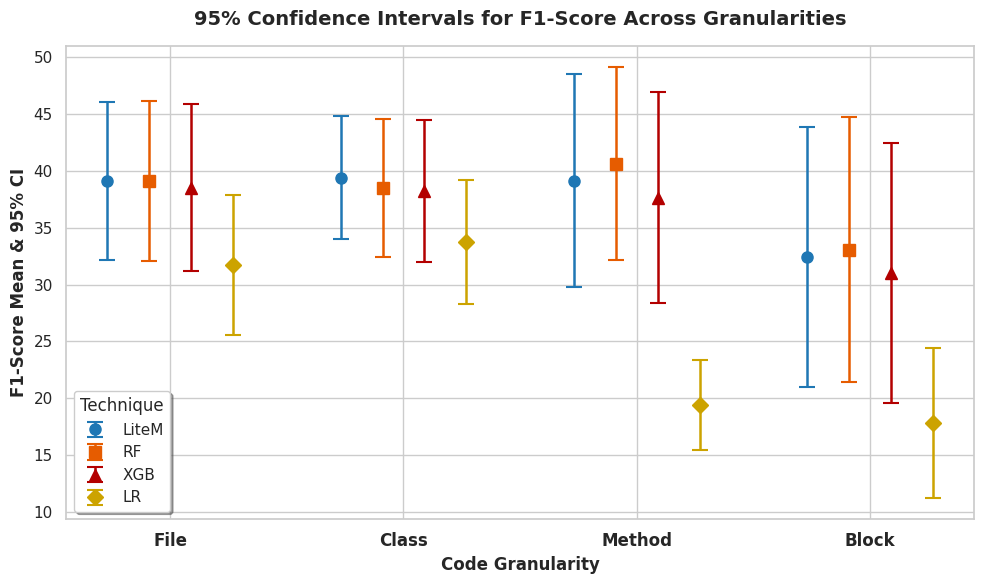

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


technique_colors = {
    # Cold color (Your main model)
    'LiteM': '#1f77b4',  # Deep Slate Blue (Stands out as the anchor)
    
    # Warm colors (The competitors)
    'RF': '#e65c00',     # Rich Orange (Warm and highly visible)
    'LR': '#cca300',     # Dark Mustard/Gold (Much easier to see than pure yellow)
    'XGB': '#b30000'     # Crimson Red (Deep and professional, not blinding)
}

# 1. Setup target metrics 
target_metrics = ["File_F1", "Class_F1", "Method_F1", "Block_F1"]
plot_data = []

# 2. Extract and format values from your existing function
for target_metric in target_metrics:
    # Get your CI summary dataframe
    ci_summary = calculate_confidence_intervals(df, target_metric)
    
    # Clean the metric name for a prettier x-axis label (e.g., "File_F1" -> "File")
    granularity = target_metric.split('_')[0]
    
    # Loop over each row (assuming columns like: Technique, Mean, Lower_95, Upper_95)
    for idx, row in ci_summary.iterrows():
        mean_val = row['Mean']
        lower_val = row['95% CI Lower']
        upper_val = row['95% CI Upper']
        
        plot_data.append({
            "Granularity": granularity,
            "Technique": row['Technique'],  # Change key if your column name differs
            "Mean": mean_val,
            "Error_Minus": mean_val - lower_val,
            "Error_Plus": upper_val - mean_val
        })

ci_plot_df = pd.DataFrame(plot_data)

# 3. Create the Error Bar Plot
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Group parameters
# # Transforma em lista
techniques = list(ci_plot_df["Technique"].unique())

# Pega do segundo elemento em diante e soma com o primeiro em uma lista
techniques = techniques[1:] + [techniques[0]]

granularities = [m.split('_')[0] for m in target_metrics]
x_coords = np.arange(len(granularities))
width = 0.18  # Spacing offset to separate the bars horizontally

# Custom markers/colors per technique
colors = [ "#1f77b4", "#e65c00", "#b30000", "#cca300",]
markers = ["o", "s", "^", "D"]

for i, tech in enumerate(techniques):
    tech_data = ci_plot_df[ci_plot_df["Technique"] == tech]
    
    # Ensure items follow the exact order of the granularities list
    means = [tech_data[tech_data["Granularity"] == g]["Mean"].values[0] for g in granularities]
    err_low = [tech_data[tech_data["Granularity"] == g]["Error_Minus"].values[0] for g in granularities]
    err_high = [tech_data[tech_data["Granularity"] == g]["Error_Plus"].values[0] for g in granularities]
    y_errors = [err_low, err_high]
    
    # Compute horizontal offset position
    pos = x_coords + (i - len(techniques)/2 + 0.5) * width
    
    ax.errorbar(pos, means, yerr=y_errors, fmt=markers[i % len(markers)], 
                color=colors[i % len(colors)], capsize=6, capthick=1.5, 
                elinewidth=1.8, ms=8, label=tech)

# Formatting axes
ax.set_xticks(x_coords)
ax.set_xticklabels(granularities, fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score Mean & 95% CI", fontsize=12, fontweight='bold')
ax.set_xlabel("Code Granularity", fontsize=12, fontweight='bold')
ax.set_title("95% Confidence Intervals for F1-Score Across Granularities", fontsize=14, fontweight='bold', pad=15)
ax.legend(title="Technique", fontsize=11, title_fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("f1_ci_comparison.png", dpi=300)
plt.show()

In [17]:
techniques = ci_plot_df["Technique"].unique()
techniques = techniques[1:], techniques[0]

techniques

(<StringArray>
 ['LiteM', 'RF', 'XGB']
 Length: 3, dtype: str,
 'LR')

In [ ]:


techniques

['LiteM', 'RF', 'XGB', 'LR']

In [7]:
# Run this in a scratch cell to see your actual column names
print(calculate_confidence_intervals(df, "File_F1").columns)

Index(['Technique', 'Sample Size (N)', 'Mean', '95% CI Lower', '95% CI Upper',
       'Margin of Error'],
      dtype='str')
